In [1]:
import os
os.chdir('/home/rsadiwa/Python/PhD/')
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, Subset, random_split, ConcatDataset
import matplotlib.pyplot as plt
import h5py
import numpy as np
import os
import math
import gc
from NN import nn_libs as icnn


In [5]:
from importlib import reload
reload(icnn)

if __name__ == "__main__":
    os.chdir('/scratch/rsadiwa/NNdataGen/May_12_fH/')
    config = icnn.hyper_parameters()
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    dummy = torch.tensor(1.0).cuda() * torch.tensor(1.0).cuda()
    # torch.set_default_device(device)
    print(f"Using device: {device}")
    # h5_file_path = "/home/rsadiwa/Python/PhD/NNDatasets/May_12_2026/master_compressed_H.h5"
    h5_file_path = "/scratch/rsadiwa/NNdataGen/May_12_fH/master_compressed.h5"
    
    # load data
    if 'shared_vram' not in globals():
        print("Initializing VRAMStorage for the first time...")
        shared_vram = icnn.VRAMStorage(h5_file_path, device=device)
    else:
        print("VRAMStorage already exists in memory. Skipping I/O load.")
    
    base_dataset = icnn.MetaMaterialDatasetPL(shared_vram, augment=False, device=device)
    # augmented data is base rotated by 90 deg
    aug_dataset  = icnn.MetaMaterialDatasetPL(shared_vram, augment=True, device=device)
    '''
    split data into 90 - 9 - 1 ratio
    Training Set - 9 - data used for training
    Validation Set - 9 - data used for validation loss
    Test Set - 1 - data for final validation. 
    
    Note:
    validation set indirectly affects training via choice of hyperparameters, 
    test set is to be use exclusively for validation during publishing
    '''
    total_size = len(base_dataset)
    train_size = int(0.90 * total_size)
    val_size   = int(0.09 * total_size)
    test_size  = total_size - train_size - val_size
        
    train_base, val_base, test_base = random_split(base_dataset, [train_size, val_size, test_size])
        
    train_aug = Subset(aug_dataset, train_base.indices)
    val_aug   = Subset(aug_dataset, val_base.indices)
    test_aug  = Subset(aug_dataset, test_base.indices)
        
    train_dataset = ConcatDataset([train_base, train_aug])
    val_dataset   = ConcatDataset([val_base, val_aug])
    test_dataset  = ConcatDataset([test_base, test_aug])
    
    gc.collect()
    torch.cuda.empty_cache()
    
    print(f"Data mapping complete!")
    print(f"Train Size: {len(train_dataset)} | Val Size: {len(val_dataset)} | Test Size: {len(test_dataset)}")
    
    subset_size = 1
    indices = np.random.choice(len(train_dataset), subset_size, replace=False)
    test_subset = Subset(train_dataset, indices)
    # test_subset = train_dataset
    
    subset_size = subset_size#//10
    indices = np.random.choice(len(val_dataset), subset_size, replace=False)
    val_subset = Subset(val_dataset, indices)
    # val_subset = val_dataset
    
    # DataLoader
    batch_size = 1
    dataloader_train = DataLoader(test_subset, batch_size=batch_size, shuffle=True,num_workers=0,pin_memory=False)
    dataloader_val   = DataLoader(val_subset,  batch_size=batch_size, shuffle=True,num_workers=0,pin_memory=False)
    # Initialize Mode
    print("\nInitializing Model...")
    try: del model
    except: pass
    model = icnn.surrogateNN(config)
    
    varW = torch.var(shared_vram.energies) 
    varS = torch.var(shared_vram.stresses)
    
    # train_model(model, dataloader_train, dataloader_val, epochs=12, lr=1e-3, device=device)
    print("=== STAGE 1: TRAINING AUTOENCODER MANIFOLD ===")
    icnn.train_model(model, dataloader_train, dataloader_val, frozen=["D"],epochs=500, lr=1e-4, device=device,varW=varW,varS=varS)
    # print("=== STAGE 1: TRAINING ICNN NETWORK ===")
    # train_model(model, dataloader_train, dataloader_val, frozen=["E","D"],epochs=20, lr=1e-3, device=device,varW=varW,varS=varS)
    # print("=== STAGE 2: TRAINING END_TO_END ===")
    # train_model(model, dataloader_train, dataloader_val, frozen=[],epochs=20, lr=1e-3, device=device,varW=varW,varS=varS)
    
    print("\n[SUCCESS] Syntax check completed perfectly.")
    
    
            
        

Using device: cuda
VRAMStorage already exists in memory. Skipping I/O load.
Data mapping complete!
Train Size: 77452 | Val Size: 7744 | Test Size: 862

Initializing Model...
=== STAGE 1: TRAINING AUTOENCODER MANIFOLD ===
--- Enforcing freeze strategy. Freezing components: ['D'] ---
-> VAE Decoder network layers FROZEN.
Epoch [1/500] Time: 0.0s
  [Train] AE Loss: 0.2488 | Energy MSE: 38.652676 | Stress MSE: 0.027958
  [Val]   AE Loss: 0.2488 | Energy MSE: 34.846363 | Stress MSE: 0.025393

Epoch [2/500] Time: 0.0s
  [Train] AE Loss: 0.2488 | Energy MSE: 38.604660 | Stress MSE: 0.028515
  [Val]   AE Loss: 0.2488 | Energy MSE: 34.907875 | Stress MSE: 0.027092

Epoch [3/500] Time: 0.0s
  [Train] AE Loss: 0.2488 | Energy MSE: 38.569275 | Stress MSE: 0.027797
  [Val]   AE Loss: 0.2488 | Energy MSE: 34.975540 | Stress MSE: 0.026579

Epoch [4/500] Time: 0.0s
  [Train] AE Loss: 0.2488 | Energy MSE: 38.561440 | Stress MSE: 0.028633
  [Val]   AE Loss: 0.2488 | Energy MSE: 34.905949 | Stress MSE: 0


--- Running Inference on Validation Batch ---


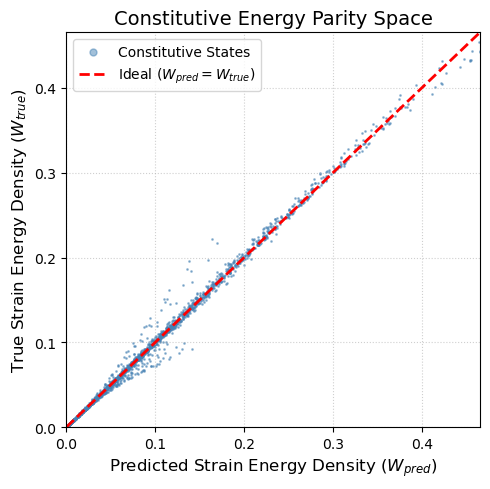


--- Energy Predictions (Joules) ---
Sample 0: True = [ 0.1241  0.1014  0.0702  0.3450  0.2028] | Pred = [ 0.1021  0.0854  0.0686  0.3460  0.1980]


IndexError: index 1 is out of bounds for axis 0 with size 1

In [6]:
def inspect_validation_batch(model, val_dataloader, device='cuda'):
    print("\n--- Running Inference on Validation Batch ---")
    
    # 1. Set model to evaluation mode (disables dropout, fixes batchnorm)
    model.eval()
    
    # 2. Grab exactly one batch of data
    images, strains, energies_true, stresses_true = next(iter(val_dataloader))
    
    # Move to GPU and ensure float32
    images = images.to(device, dtype=torch.float32)
    strains = strains.to(device, dtype=torch.float32)
    energies_true = energies_true.to(device, dtype=torch.float32)
    stresses_true = stresses_true.to(device, dtype=torch.float32)
    
    # 3. CRITICAL: We need gradients for the strain to calculate stress!
    strains.requires_grad_(True)
    
    # 4. Forward Pass
    W_pred, recon_images, mu, logvar = model(images, strains)
    
    # 5. Calculate Stress (Derivative of W_pred wrt strains)
    # Note: create_graph=False is fine here since we aren't backpropagating to update model weights
    S_pred = torch.autograd.grad(
        outputs=W_pred, 
        inputs=strains, 
        grad_outputs=torch.ones_like(W_pred), 
        create_graph=False
    )[0]
    
    # Move tensors back to CPU for printing and plotting
    W_pred = W_pred.detach().cpu().numpy()
    S_pred = S_pred.detach().cpu().numpy()
    energies_true = energies_true.cpu().numpy()
    stresses_true = stresses_true.cpu().numpy()
    
    # print(energies_true.mean(), energies_true.std())
    # print(W_pred.mean(), W_pred.std())
    from matplotlib import pyplot as plt
    w_pred = W_pred.flatten()
    w_true = energies_true.flatten()
    plot_max = max(w_pred.max(), w_true.max())

    plt.figure(figsize=(5, 5)) # Force a square aspect ratio
    plt.scatter(w_pred, w_true, s=1, alpha=0.5, color='steelblue', label='Constitutive States')
    plt.plot([0, plot_max], [0, plot_max], 'r--', linewidth=2, label='Ideal ($W_{pred} = W_{true}$)')

    plt.xlabel('Predicted Strain Energy Density ($W_{pred}$)', fontsize=12)
    plt.ylabel('True Strain Energy Density ($W_{true}$)', fontsize=12)
    plt.title('Constitutive Energy Parity Space', fontsize=14)
    plt.xlim(0, plot_max)
    plt.ylim(0, plot_max)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', markerscale=5) # markerscale makes the legend dot visible

    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # PRINT PHYSICAL VALUES (First 5 samples)
    # ==========================================
    np.set_printoptions(formatter={'float': '{: 0.4f}'.format})
    print(f"\n--- Energy Predictions (Joules) ---")
    i2p = [0,5,149,127,299]
    for i in range(5):
        print(f"Sample {i}: True = {energies_true[i,i2p,-2]} | Pred = {W_pred[i,i2p,-2][...,0]}")
        
    print(f"\n--- Stress Predictions (S11, S22, S12) ---")
    for i in range(5):
        print(f"Sample {i}:")
        print(f"  True: {stresses_true[i,i2p,-1]}")
        print(f"  Pred: {S_pred[i,i2p,-1]}")
        print(f"  Diff: {abs(stresses_true[i,i2p,-1] - S_pred[i,i2p,-1])}")

    # ==========================================
    # PLOT RECONSTRUCTIONS (Autoencoder check)
    # ==========================================
    orig_imgs = images.detach().cpu().numpy()
    rec_imgs = recon_images.detach().cpu().numpy()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    plt.suptitle("Autoencoder Reconstructions (Top: Original | Bottom: Generated)")
    
    for i in range(5):
        # Original (Top row)
        axes[0, i].imshow(orig_imgs[i][0], cmap='Grays')
        axes[0, i].axis('off')
        # Reconstructed (Bottom row)
        axes[1, i].imshow(rec_imgs[i][0], cmap='Grays')
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it
dv2 = DataLoader(test_subset,  batch_size=batch_size, shuffle=True,num_workers=0,pin_memory=False)
inspect_validation_batch(model, dv2, device=device)

In [ ]:
raise

In [ ]:
import torch
import gc

def hunt_fat_tensors(top_n=15):
    """Searches memory for the largest active PyTorch tensors and prints them."""
    print(f"\n--- HUNTING TOP {top_n} LARGEST TENSORS IN VRAM ---")
    
    tensors = []
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                # Calculate size in GB
                size_gb = obj.element_size() * obj.nelement() / (1024 ** 3)
                if size_gb > 0.01:  # Only care about tensors larger than 10MB
                    tensors.append((size_gb, obj.size(), obj.dtype, obj.device))
        except:
            pass # Some objects in gc are protected or restricted
            
    # Sort by size (descending)
    tensors.sort(key=lambda x: x[0], reverse=True)
    
    for i, (size, shape, dtype, device) in enumerate(tensors[:top_n]):
        print(f"#{i+1}: {size:.3f} GB | Shape: {list(shape)} | Type: {dtype} | On: {device}")
    print("--------------------------------------------------\n")

# Usage:
hunt_fat_tensors()